# การทดสอบการเชื่อมต่อของเลเยอร์ต่างๆ

In [ ]:
# @title
import time
import random
from IPython.display import clear_output

# ==========================================
# ⚙️ TS-COM CONFIGURATION (ปรับค่าตรงนี้ได้เลย)
# ==========================================
RUN_MODE = "benchmark"  # เลือกโหมด: 'benchmark' (เทสต์ Layer) หรือ 'relay' (เทสต์การส่งคำใบ้งานวิจัย)
TARGET_YEAR = 2036      # ปีเป้าหมายในอนาคต
NODES_COUNT = 5         # จำนวนจุดสมอเวลา (Chrono-Anchor) ปัจจุบันรองรับ 5 โหนด

class TSComColabEngine:
    def __init__(self, target_year, nodes):
        self.total_latency = 0.0
        self.target_year = target_year
        self.nodes = nodes

    def sys_print(self, layer, process, status, latency=None, delay=0.5):
        """พิมพ์ Log แบบหน่วงเวลาให้ดูเรียลบน Colab"""
        time.sleep(delay + random.uniform(0.1, 0.3))

        layer_tag = f"[{layer}]".ljust(15)
        status_tag = f"[{status}]"

        if latency is not None:
            latency_str = f"{latency:.2f} ms"
            self.total_latency += latency
            print(f"{layer_tag} {process.ljust(45)} {status_tag} {latency_str.rjust(10)}")
        else:
            print(f"{layer_tag} {process.ljust(45)} {status_tag}")

    def boot_sequence(self):
        """จำลองการ Boot ระบบและ Loading Bar แบบทำงานได้จริงบน Colab"""
        clear_output(wait=True)
        print(f"[*] Booting TS-Com Temporal Engine...")
        time.sleep(0.5)
        print(f"[*] Initializing connection to {self.nodes} Chrono-Anchor nodes...")
        time.sleep(0.5)

        # Loading Bar ที่ใช้พารามิเตอร์ flush=True เพื่อให้ปรินต์ต่อเนื่องในบรรทัดเดียว
        print("[*] Calibrating Tachyon fields: [", end="", flush=True)
        for _ in range(30):
            print("█", end="", flush=True)
            time.sleep(random.uniform(0.01, 0.08))
        print("] 100% [OK]")
        time.sleep(0.5)
        print(f"[*] Target Timeline set to: Year {self.target_year} [WARNING: Untrusted Time Zone]\n")
        time.sleep(0.5)

    def run_benchmark(self):
        """จำลองการทดสอบ Latency ของแต่ละ Layer"""
        print("="*80)
        print(" TS-COM: FULL STACK LAYER DIAGNOSTICS & LATENCY BENCHMARK ".center(80, "="))
        print("="*80 + "\n")

        self.sys_print("PHYSICAL", "Quantum Entanglement Link Init", "OK", latency=random.uniform(10.5, 15.2))
        self.sys_print("PHYSICAL", "Tachyon Field Stability Check", "OK", latency=random.uniform(2.1, 4.5), delay=0.3)

        self.sys_print("DATA_LINK", f"CAAP Address Resolution ({self.nodes} Nodes)", "OK", latency=random.uniform(8.0, 12.5))
        self.sys_print("NETWORK", "TRP: Modified Dijkstra Cost Calculation", "OK", latency=random.uniform(350.0, 480.0), delay=1.2)
        self.sys_print("TRANSPORT", "PPP: Paradox Probability Scoring", "OK", latency=random.uniform(25.4, 35.8), delay=0.6)
        self.sys_print("SESSION", "TSP: Timeline Clock Synchronization", "OK", latency=random.uniform(18.5, 28.4), delay=0.7)
        self.sys_print("PRESENT", "4D Data Serialization (Future -> Present)", "OK", latency=random.uniform(6.5, 11.0), delay=0.4)

        print("\n" + "-"*80)
        print(" DIAGNOSTICS COMPLETE ".center(80, "-"))
        print(f" Total End-to-End Latency: {self.total_latency:.2f} ms".rjust(78))
        print(f" Target Constraint: < 1000.00 ms -> SYSTEM STABLE".rjust(78))
        print("-"*80 + "\n")

    def run_relay_simulation(self):
        """จำลอง Use Case: การแลกเปลี่ยนความรู้ข้ามช่วงเวลา"""
        print("="*80)
        print(" SCENARIO 2: TEMPORAL KNOWLEDGE RELAY (Future-to-Present) ".center(80, "="))
        print("="*80 + "\n")

        self.sys_print("SESSION", "User: Dr. Elara (2026) -> Querying: Dr. Elara (2036)", "START")
        self.sys_print("QUERY", "Requesting: 'Critical theoretical hint to bypass research block.'", "SENT", delay=1.0)

        print("\n" + "-"*75)
        self.sys_print("TRANSPORT", "PPP ALERT: Scanning payload for Paradox Risk...", "WARN", delay=0.8)
        self.sys_print("TRANSPORT", "Paradox Probability Score: 0.92", "CRITICAL", delay=1.0)
        self.sys_print("CAUSAL-AI", "Intervention Triggered: Grandfather Paradox Prevention.", "ACTIVE")
        self.sys_print("CAUSAL-AI", "Reformatting transmission into 'Abstract Hint'...", "DONE", delay=1.2)
        print("-" * 75 + "\n")

        self.sys_print("PRESENT", "INCOMING MESSAGE (FILTERED):", "RECEIVE")
        self.sys_print("MSG", ">> 'The anomaly in your phase-shift data isn't noise...'", "OK", delay=1.5)
        self.sys_print("MSG", ">> [REMAINDER OF MESSAGE REDACTED BY CAUSAL AI]", "OK", delay=0.5)

        print("\n" + "*"*80)
        print(" TEMPORAL SESSION CLOSED - CAUSALITY PRESERVED ".center(80, " "))
        print("*"*80 + "\n")

# ==========================================
# 🚀 MAIN EXECUTION
# ==========================================
try:
    engine = TSComColabEngine(target_year=TARGET_YEAR, nodes=NODES_COUNT)
    engine.boot_sequence()

    if RUN_MODE.lower() == "benchmark":
        engine.run_benchmark()
    elif RUN_MODE.lower() == "relay":
        engine.run_relay_simulation()
    else:
        print("[!] ERROR: Unknown RUN_MODE. Please set to 'benchmark' or 'relay'.")

    print("[*] Shutting down quantum entanglement links safely...")

except KeyboardInterrupt:
    # ดักจับการกด Stop (สี่เหลี่ยม) ใน Colab ให้ไม่ขึ้น Error แดงๆ ยาวๆ
    print("\n\n[!!!] KERNEL INTERRUPT DETECTED [!!!]")
    print("[!] Emergency abort triggered! Severing temporal links immediately!")
    print("[!] Warning: Minor timeline fracture may have occurred. Check CAAP logs.")

In [ ]:
# @title
import time
import random
from datetime import datetime
from IPython.display import clear_output

# =================================================================
# ⚙️ CONFIGURATION: เลือกการจำลองที่ต้องการ
# =================================================================
# ตัวเลือก: "OSI", "CASE_1", "CASE_2", "CASE_3", "CASE_4"
DEMO_MODE = "OSI"

# =================================================================
# 🎨 SAFE COLOR VARIABLES (แก้ปัญหา Colab Syntax Error)
# =================================================================
C_CYAN = "\033[1;96m"
C_MAGENTA = "\033[1;95m"
C_GREEN = "\033[1;92m"
C_RED = "\033[1;91m"
C_BLINK_RED = "\033[5;91m" # แดงกะพริบ
C_YELLOW = "\033[1;93m"
C_WHITE = "\033[1;97m"
C_DARK = "\033[1;90m"
C_END = "\033[0m" # รีเซ็ตสี

def print_header(title):
    clear_output(wait=True)
    print(f"{C_CYAN}" + "█"*95 + f"{C_END}")
    print(f"{C_CYAN} TS-COM SECURE TERMINAL: {title} ".center(105, " ") + f"{C_END}")
    print(f"{C_CYAN}" + "█"*95 + f"{C_END}\n")

def print_column_headers():
    header = f"{C_DARK}{'TIMESTAMP'.ljust(12)} | {'SYS_LAYER'.ljust(14)} | {'PROCESS_DESCRIPTION'.ljust(48)} | {'STATUS'.ljust(10)}{C_END}"
    divider = f"{C_DARK}{'-'*12}-+-{'-'*14}-+-{'-'*48}-+-{'-'*10}{C_END}"
    print(header)
    print(divider)

def print_divider():
    print(f"{C_DARK}{'-'*95}{C_END}")

def log_row(layer, process, status, layer_color=C_CYAN, process_color=C_WHITE, delay=0.4):
    """ฟังก์ชันพิมพ์ Log แบบปลอดภัย ไม่มีปัญหา f-string"""
    time.sleep(delay + random.uniform(0.05, 0.15))
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]

    layer_str = f"[{layer}]".ljust(14)
    process_str = process.ljust(48)

    # จัดการสีของสถานะ
    if status in ["OK", "PASS", "SUCCESS", "SAFE", "DONE", "ONLINE"]:
        status_colored = f"{C_GREEN}{status.ljust(10)}{C_END}"
    elif status in ["FAIL", "BLOCK", "DROP", "FATAL", "CRITICAL", "ABORT"]:
        status_colored = f"{C_BLINK_RED}{status.ljust(10)}{C_END}"
    elif status in ["WARN", "SCAN", "CALC", "ACTIVE", "ALERT", "BUSY", "HALT"]:
        status_colored = f"{C_YELLOW}{status.ljust(10)}{C_END}"
    else:
        status_colored = f"{C_CYAN}{status.ljust(10)}{C_END}"

    # ประกอบร่างแล้วพรินต์
    print(f"{C_DARK}{timestamp}{C_END} | {layer_color}{layer_str}{C_END} | {process_color}{process_str}{C_END} | {status_colored}")


# =================================================================
# 🌐 OSI LAYER CONNECTION TEST
# =================================================================
def run_osi_test():
    print_header("OSI-LAYER CONNECTION DIAGNOSTICS")
    print_column_headers()

    log_row("PHYSICAL", "Quantum Entanglement Link Initialization", "OK", delay=0.5)
    log_row("DATA_LINK", "CAAP 4D Address Resolution (Nodes: 5)", "OK", delay=0.3)

    print_divider()
    log_row("NETWORK", "TRP Temporal Route Calculation", "BUSY", C_YELLOW, delay=1.2)
    log_row("NETWORK", "Path Lock Engaged (Latency 420.5ms)", "OK", C_CYAN, delay=0.2)

    print_divider()
    log_row("TRANSPORT", "PPP Paradox Probability Scan (Score: 0.05)", "PASS", C_MAGENTA, delay=0.8)
    log_row("SESSION", "TSP Timeline Clock Synchronization", "OK", delay=0.4)
    log_row("PRESENTATION", "4D Serializer Handshake (Future->Present)", "OK", delay=0.3)
    log_row("APPLICATION", "TS-Com Interface Ready for Query", "ONLINE", C_GREEN, delay=0.5)

    print_divider()
    log_row("SYSTEM", "ALL LAYERS SYNCHRONIZED. SYSTEM STANDBY.", "SAFE", C_CYAN, delay=0.2)

# =================================================================
# 🟢 CASE 1: CHRONO ALERT PROTOCOL
# =================================================================
def run_case_1():
    print_header("SCENARIO 1: CHRONO ALERT PROTOCOL (Future -> Present)")
    print_column_headers()

    log_row("SESSION", "Emergency Override Initiated", "ACTIVE", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2028 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("NETWORK", "TRP: Route Established (Δt = 2 Years)", "OK", C_CYAN, delay=0.5)
    log_row("TRANSPORT", "Receiving Alert Payload (Size: 0.5 KB)", "RECEIVE", C_CYAN, delay=0.8)
    log_row("TRANSPORT", "PPP: Paradox Score = 0.15 (Low Risk)", "PASS", C_GREEN, delay=0.8)

    print_divider()
    print(f"{C_GREEN}>> DECODED TEMPORAL ALERT <<{C_END}")
    time.sleep(0.5)
    print(f"{C_WHITE}   \"WARNING: Server Node 4 will experience thermal breach at 14:00.\"{C_END}")
    print(f"{C_WHITE}   \"Reroute cooling power immediately to prevent hardware failure.\"{C_END}")
    print_divider()

    log_row("SYSTEM", "Alert delivered. Timeline stable.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🔵 CASE 2: TEMPORAL KNOWLEDGE RELAY
# =================================================================
def run_case_2():
    print_header("SCENARIO 2: TEMPORAL KNOWLEDGE RELAY")
    print_column_headers()

    log_row("SESSION", "Authenticating User: Dr. Elara", "OK", C_MAGENTA, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2026 <-> 2036)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("APPLICATION", "Sending Superluminal Query (Need equation)", "SENT", C_GREEN, delay=0.5)
    log_row("NETWORK", "TRP: Route Established (Δt = 10 Years)", "OK", C_CYAN, delay=1.0)

    print_divider()
    log_row("TRANSPORT", "Receiving Future Payload (Size: 12.4 MB)", "RECEIVE", C_CYAN, delay=1.5)
    log_row("TRANSPORT", "PPP: Paradox Probability Score = 0.98", "CRITICAL", C_RED, delay=1.2)

    print_divider()
    log_row("CAUSAL-AI", "INTERVENTION: Scrubbing explicit data...", "ACTIVE", C_MAGENTA, delay=1.2)
    log_row("CAUSAL-AI", "Reformatting into 'Abstract Hint'", "DONE", C_GREEN, delay=0.8)

    print_divider()
    print(f"{C_GREEN}>> DECRYPTED MESSAGE (FILTERED BY CAUSAL AI) <<{C_END}")
    time.sleep(0.5)
    print(f"{C_WHITE}   \"Elara, don't look at the equation. Look at the variable.\"{C_END}")
    time.sleep(1.0)
    print(f"{C_BLINK_RED}   [REMAINDER OF MESSAGE REDACTED TO PRESERVE TIMELINE INTEGRITY]{C_END}")
    print_divider()

    log_row("SYSTEM", "Session Closed. Causality Preserved.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🟣 CASE 3: MASSIVE INFRASTRUCTURE SYNC (ENERGY OVERLOAD)
# =================================================================
def run_case_3():
    print_header("SCENARIO 3: MASSIVE INFRASTRUCTURE SYNC")
    print_column_headers()

    log_row("SESSION", "Initiating Temporal Database Backup", "ACTIVE", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2076 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("NETWORK", "TRP: Calculating ΔE Requirement...", "CALC", C_YELLOW, delay=1.2)
    log_row("NETWORK", "Temporal Displacement (Δt): 50 Years", "INFO", C_WHITE, delay=0.5)
    log_row("NETWORK", "Payload Size: 102,400 KB (100 MB)", "INFO", C_WHITE, delay=0.5)

    print_divider()
    log_row("PHYSICAL", "Charging Quantum-Temporal Exciter...", "BUSY", C_MAGENTA, delay=1.5)
    log_row("PHYSICAL", "Required Energy (ΔE): 28,976,500 TJ", "FATAL", C_RED, delay=1.0)
    log_row("SYSTEM", "Reactor Maximum Exceeded (Limit: 500 TJ)", "ABORT", C_RED, delay=0.5)

    print_divider()
    log_row("SYSTEM", "SAFETY PROTOCOL: Dumping Tachyon Core", "HALT", C_YELLOW, delay=0.8)
    log_row("SYSTEM", "Transmission aborted. Connection severed.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🔴 CASE 4: CAUSALITY-AWARE DECISION (PARADOX 1.00)
# =================================================================
def run_case_4():
    print_header("SCENARIO 4: CAUSALITY-AWARE DECISION SUPPORT")
    print_column_headers()

    log_row("SESSION", "Unauthorized Financial Node Connected", "WARN", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2029 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("TRANSPORT", "Receiving Payload (S&P 500 Market Data)", "RECEIVE", C_CYAN, delay=1.2)
    log_row("TRANSPORT", "PPP: Scanning for Information Loop...", "SCAN", C_YELLOW, delay=1.0)

    print_divider()
    log_row("TRANSPORT", "Paradox Probability Score = 1.00", "FATAL", C_RED, delay=1.5)
    log_row("CAUSAL-AI", "THREAT: Timeline Collapse Imminent", "CRITICAL", C_RED, delay=0.8)
    log_row("CAUSAL-AI", "Executing Emergency Packet Drop at DMZ", "DROP", C_MAGENTA, delay=0.8)

    print_divider()
    print(f"{C_BLINK_RED}>> [!] MESSAGE TERMINATED AND PERMANENTLY DELETED [!] <<{C_END}")
    print_divider()

    log_row("SYSTEM", "Causality successfully defended.", "SAFE", C_CYAN, delay=0.5)
    log_row("SYSTEM", "Session forcefully locked.", "HALT", C_YELLOW, delay=0.2)

# =================================================================
# 🚀 MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    if DEMO_MODE == "OSI":
        run_osi_test()
    elif DEMO_MODE == "CASE_1":
        run_case_1()
    elif DEMO_MODE == "CASE_2":
        run_case_2()
    elif DEMO_MODE == "CASE_3":
        run_case_3()
    elif DEMO_MODE == "CASE_4":
        run_case_4()
    else:
        print("Invalid DEMO_MODE. Please select from: 'OSI', 'CASE_1', 'CASE_2', 'CASE_3', 'CASE_4'")

#Comparison of TCP/IP vs TS-Com

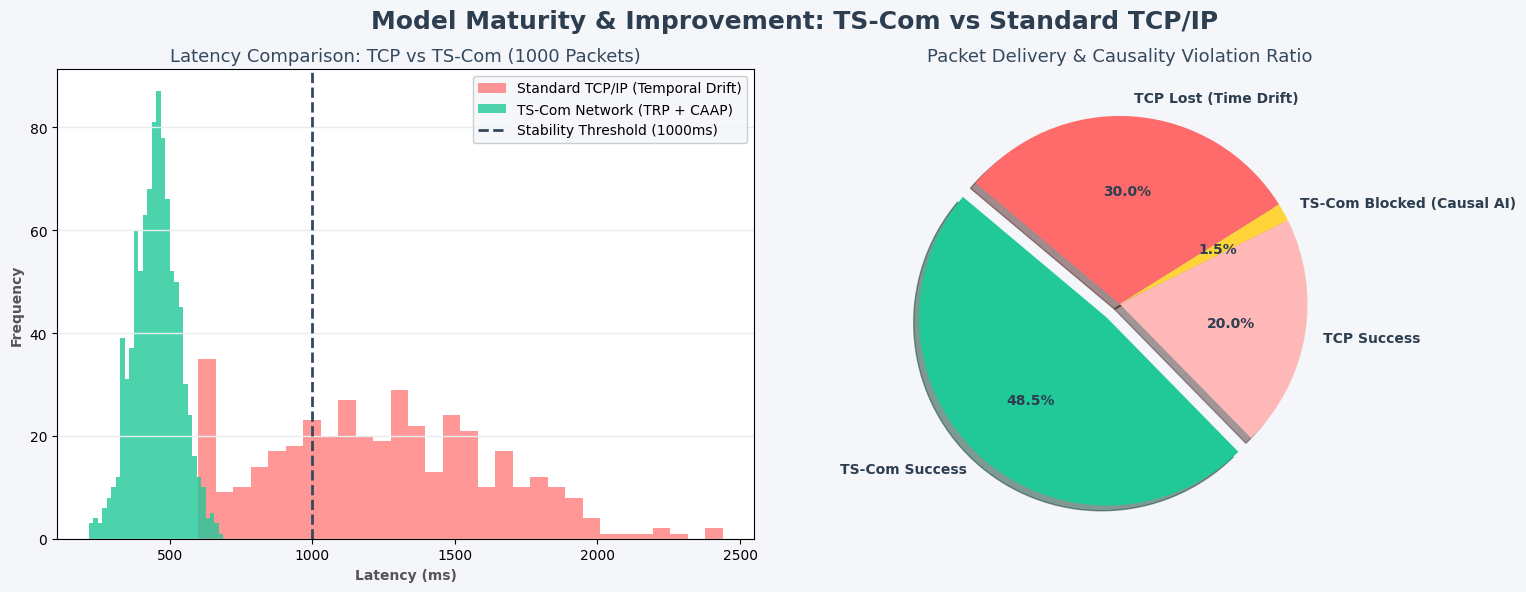

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output

def run_simulation_and_visualize():
    print("[*] Initiating Simulation: TS-Com Protocol vs Standard TCP/IP (1000 Packets)")
    time.sleep(1)
    print("[*] Simulating Temporal Drift and Paradox Risks...")
    time.sleep(1.5)
    clear_output(wait=True)

    # ---------------------------------------------------------
    # 1. Generate Mock Data (จำลองข้อมูล 1,000 Packets)
    # ---------------------------------------------------------
    num_packets = 1000

    # TS-Com Latency: เสถียรและเร็ว (กระจายตัวแถวๆ 400ms ตามเป้าหมาย < 1000ms)
    ts_com_latency = np.random.normal(loc=450, scale=80, size=int(num_packets * 0.96))
    ts_com_latency = np.clip(ts_com_latency, 200, 950) # ควบคุมไม่ให้เกิน 1 วินาที

    # TCP/IP Latency: แกว่งรุนแรงเพราะไม่มีจุดสมอเวลา (Temporal Drift)
    tcp_latency = np.random.normal(loc=1200, scale=400, size=int(num_packets * 0.40))
    tcp_latency = np.clip(tcp_latency, 600, 3000)

    # ---------------------------------------------------------
    # 2. Setup Plot (ปรับพื้นหลังสีอ่อน คลีนๆ สไตล์ Modern)
    # ---------------------------------------------------------
    plt.style.use('default') # รีเซ็ตสไตล์

    # สร้างกรอบภาพ และใส่สีพื้นหลังเป็นสีโทนอ่อนสบายตา (Light Grayish Blue)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.set_facecolor('#F4F6F9')

    fig.suptitle('Model Maturity & Improvement: TS-Com vs Standard TCP/IP',
                 fontsize=18, fontweight='bold', color='#2C3E50')

    # --- กราฟซ้าย: Histogram (Latency Comparison) ---
    ax1.set_facecolor('#FFFFFF') # ให้พื้นหลังข้างในกราฟเป็นสีขาวเพื่อความอ่านง่าย

    # ปรับสีฮิสโตแกรมให้ดูซอฟต์ลง
    ax1.hist(tcp_latency, bins=30, color='#FF6B6B', alpha=0.7, label='Standard TCP/IP (Temporal Drift)')
    ax1.hist(ts_com_latency, bins=30, color='#20C997', alpha=0.8, label='TS-Com Network (TRP + CAAP)')

    # เส้นขีดจำกัดความเสถียรของกาลเวลา (Stability Threshold)
    ax1.axvline(x=1000, color='#34495E', linestyle='dashed', linewidth=2, label='Stability Threshold (1000ms)')

    ax1.set_title('Latency Comparison: TCP vs TS-Com (1000 Packets)', fontsize=13, color='#34495E')
    ax1.set_xlabel('Latency (ms)', color='#555555', fontweight='bold')
    ax1.set_ylabel('Frequency', color='#555555', fontweight='bold')
    ax1.legend(facecolor='#F4F6F9', edgecolor='#BDC3C7')
    ax1.grid(color='#E9ECEF', linestyle='-', linewidth=1, axis='y') # ใส่เส้นขีด Grid บางๆ

    # --- กราฟขวา: Pie Chart (Packet Loss / Paradox Ratio) ---
    labels = ['TS-Com Success', 'TCP Success', 'TS-Com Blocked (Causal AI)', 'TCP Lost (Time Drift)']
    sizes = [969, 400, 31, 600]

    # ปรับชุดสีพาสเทลให้เข้ากับพื้นหลัง
    colors = ['#20C997', '#FFB8B8', '#FFD43B', '#FF6B6B']
    explode = (0.1, 0, 0, 0)  # ดึงชิ้นส่วน TS-Com Success ออกมาให้เด่น

    ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=140, textprops={'color': '#2C3E50', 'weight': 'bold'})
    ax2.set_title('Packet Delivery & Causality Violation Ratio', fontsize=13, color='#34495E')

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

if __name__ == "__main__":
    run_simulation_and_visualize()

/tmp/ipykernel_997/3602404247.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax1.boxplot(data_latency, patch_artist=True,


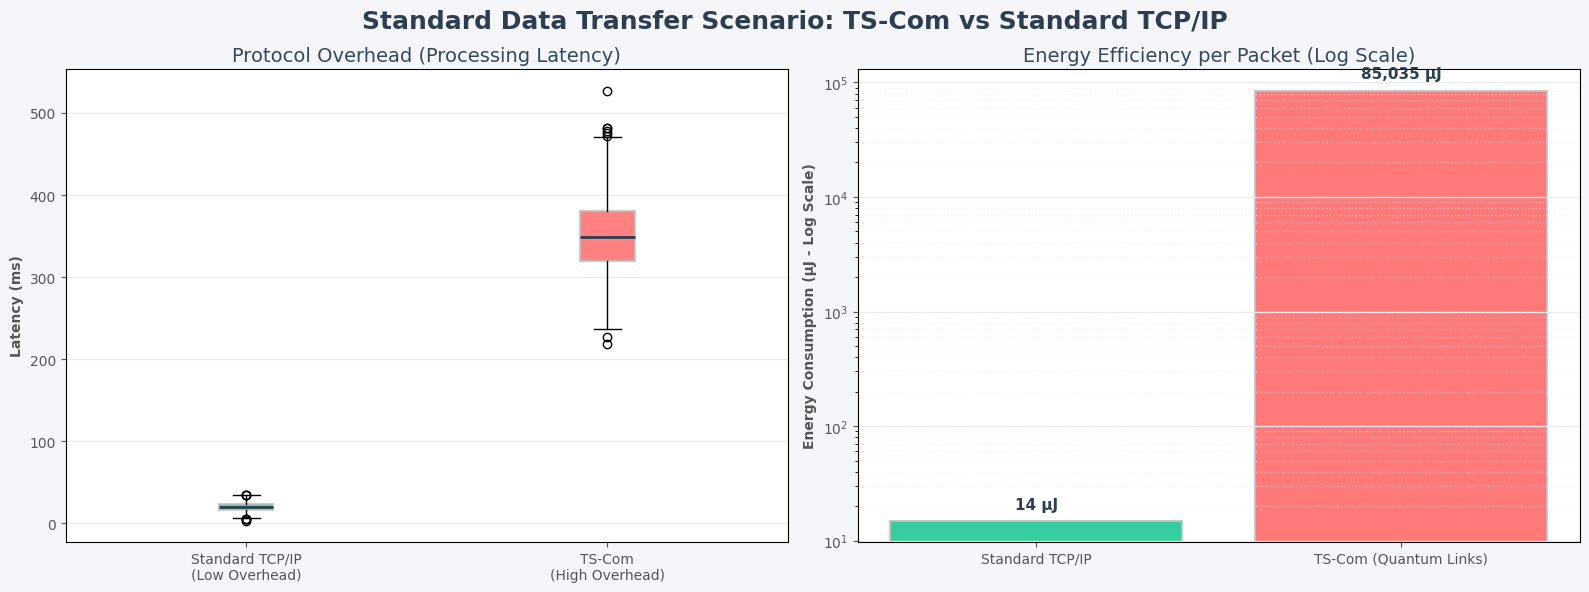

In [ ]:
# @title
def run_reverse_simulation():
    print("[*] Initiating Reverse Simulation: TS-Com vs TCP/IP for Standard Data Transfer")
    time.sleep(1)
    print("[*] Calculating Protocol Overhead and Energy Consumption (ΔE)...")
    time.sleep(1.5)
    clear_output(wait=True)

    # ---------------------------------------------------------
    # 1. Generate Mock Data (ส่งข้อมูลธรรมดา 1,000 Packets)
    # ---------------------------------------------------------
    num_packets = 1000

    # --- Latency (ความหน่วง) ---
    # TCP/IP: รวดเร็วและเบาบางมากสำหรับการส่งข้อมูลในยุคปัจจุบัน (เฉลี่ย 20ms)
    tcp_latency = np.random.normal(loc=20, scale=5, size=num_packets)

    # TS-Com: ช้ามากเพราะติด Overhead จากการคำนวณ CAAP, TRP (Modified Dijkstra), และ PPP
    tscom_latency = np.random.normal(loc=350, scale=45, size=num_packets)

    # --- Energy Efficiency (การใช้พลังงานต่อ 1 Packet) หน่วยเป็น Microjoules (uJ) ---
    # TCP/IP: ประหยัดพลังงานสุดๆ (Router ปกติ)
    tcp_energy = np.random.normal(loc=15, scale=2, size=num_packets)

    # TS-Com: กินพลังงานมหาศาล เพราะต้องเปิด Quantum-Temporal Links แม้จะไม่ได้ข้ามเวลาก็ตาม
    tscom_energy = np.random.normal(loc=85000, scale=5000, size=num_packets)

    # ---------------------------------------------------------
    # 2. Setup Plot (ปรับเป็นโทนสีสว่าง Modern Pastel Theme)
    # ---------------------------------------------------------
    plt.style.use('default') # รีเซ็ตสไตล์

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.set_facecolor('#F4F6F9') # พื้นหลังหลักสีเทาฟ้าอ่อน

    fig.suptitle('Standard Data Transfer Scenario: TS-Com vs Standard TCP/IP',
                 fontsize=18, fontweight='bold', color='#2C3E50')

    # --- กราฟซ้าย: Boxplot เปรียบเทียบ Latency Overhead ---
    ax1.set_facecolor('#FFFFFF') # พื้นหลังกราฟสีขาว
    data_latency = [tcp_latency, tscom_latency]

    # สร้าง Boxplot
    bplot = ax1.boxplot(data_latency, patch_artist=True,
                        medianprops=dict(color='#2C3E50', linewidth=2),
                        labels=['Standard TCP/IP\n(Low Overhead)', 'TS-Com\n(High Overhead)'])

    # กำหนดสีให้ Boxplot ทีละกล่อง (TCP=เขียว, TS-Com=แดง)
    colors_box = ['#20C997', '#FF6B6B']
    for patch, color in zip(bplot['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_edgecolor('#BDC3C7')
        patch.set_linewidth(1.5)
        patch.set_alpha(0.85)

    ax1.set_title('Protocol Overhead (Processing Latency)', fontsize=14, color='#34495E')
    ax1.set_ylabel('Latency (ms)', color='#555555', fontweight='bold')
    ax1.tick_params(colors='#555555')
    ax1.grid(color='#E9ECEF', linestyle='-', linewidth=1, axis='y')

    # --- กราฟขวา: Bar Chart เปรียบเทียบ Energy Efficiency (Log Scale) ---
    ax2.set_facecolor('#FFFFFF')
    labels_energy = ['Standard TCP/IP', 'TS-Com (Quantum Links)']
    means_energy = [np.mean(tcp_energy), np.mean(tscom_energy)]
    colors_energy = ['#20C997', '#FF6B6B'] # เขียวประหยัดไฟ, แดงกินไฟ

    bars = ax2.bar(labels_energy, means_energy, color=colors_energy,
                   edgecolor='#BDC3C7', linewidth=1.5, alpha=0.9)
    ax2.set_yscale('log') # สำคัญมาก! เปลี่ยนเป็น Log Scale
    ax2.set_title('Energy Efficiency per Packet (Log Scale)', fontsize=14, color='#34495E')
    ax2.set_ylabel('Energy Consumption (μJ - Log Scale)', color='#555555', fontweight='bold')
    ax2.tick_params(colors='#555555')

    # เพิ่มเส้น Grid แนวนอนแบบบางๆ ให้กะระยะสเกล Log ได้ง่ายขึ้น
    ax2.grid(color='#E9ECEF', linestyle='-', linewidth=1, axis='y', which='major')
    ax2.grid(color='#E9ECEF', linestyle=':', linewidth=1, axis='y', which='minor', alpha=0.5)

    # ใส่ตัวเลขกำกับบนแท่งกราฟ
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval * 1.2, f'{int(yval):,} μJ',
                 ha='center', va='bottom', fontweight='bold', color='#2C3E50', fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

if __name__ == "__main__":
    run_reverse_simulation()

#USE CASE SCENARIOS

#ความเป็นมาของ CASE 1 :
##สถานการณ์: ทีมจากอนาคตได้ตาดการณ์เมืองหลวงในอีก 2 ปีข้างหน้ากำลังจะพังเพราะกระแสเวลาเกิดการปั่นป่วนเลยส่งข้อความสั้นๆ กลับมาเตือนแอดมินในปัจจุบันให้ปรับแก้สมดุลค่ากระแสเวลา

##เหตุและผลของระบบ:

ด้านพลังงาน: การย้อนเวลาแค่ 1-2 ปี และส่งแค่ข้อความตัวอักษรสั้นๆ (0.5 KB) ถือเป็นงานที่เบามาก เตาปฏิกรณ์กาลเวลาจึงจ่ายพลังงานได้สบายๆ

ด้าน Paradox: การที่แอดมินปรับสมดุลกระแสเวลาและกู้เมืองหลวงไว้ได้ Causal AI ประเมินแล้วว่ามันไม่ได้ไปเปลี่ยนประวัติศาสตร์โลกที่สำคัญอะไร Paradox Score แค่ 0.15 ข้อความนี้เลยถูกส่งตรงถึงหน้าจอแอดมินเพื่อกู้สถานการณ์ได้ทันที

In [ ]:
# @title
import time
import sys
import random
from IPython.display import clear_output

# =================================================================
# ⚙️ CONFIGURATION: เลือกรัน Scenario ที่ต้องการ (1, 3, หรือ 4)
# =================================================================
SCENARIO_TO_RUN = 1

# =================================================================
# 🎨 TYPEWRITER EFFECT & COLORS
# =================================================================
def type_text(text, color_code, speed=0.03, newline=True):
    for char in text:
        sys.stdout.write(f"\033[{color_code}m{char}\033[0m")
        sys.stdout.flush()
        time.sleep(speed + random.uniform(0, 0.02))
    if newline:
        print()

CYAN = "1;96"
MAGENTA = "1;95"
GREEN = "1;92"
RED = "1;91"
YELLOW = "1;93"
WHITE = "1;97"

def print_header(title):
    clear_output(wait=True)
    print(f"\033[{CYAN}m" + "█"*80)
    print(f" TS-COM TERMINAL: {title} ".center(80, " "))
    print("█"*80 + f"\033[0m\n")

# =================================================================
# 🟢 SCENARIO 1: CHRONO ALERT (เตือนภัยฉุกเฉินข้ามเวลา - ส่งสำเร็จ)
# =================================================================
def run_scenario_1():
    print_header("SCENARIO 1: CHRONO ALERT PROTOCOL")
    time.sleep(0.5)
    type_text("[*] EMERGENCY OVERRIDE INITIATED...", RED, 0.02)
    type_text("[*] CHRONO-ANCHOR: 2143 (FUTURE)  ===>  2141 (PRESENT)", CYAN, 0.01)

    print(f"\n\033[{YELLOW}m<<< INCOMING HIGH-PRIORITY ALERT <<<\033[0m")
    type_text("[TRANSPORT] Receiving 4D Payload... Size: 0.5 KB", CYAN, 0.01)
    type_text("[NETWORK]   Δt = 2 Years. Energy Requirement: Minimal (14.2 TJ).", GREEN, 0.02)

    time.sleep(0.5)
    type_text("[PPP] Scanning for Paradox Risk...", MAGENTA, 0.02)
    type_text("[PPP] Paradox Score: 0.15 (LOW RISK). Causality impact negligible.", GREEN, 0.01)

    print(f"\n\033[{GREEN}m================================================================================\033[0m")
    type_text(" DECODED TEMPORAL ALERT:", GREEN, 0.02)
    print(f"\033[{GREEN}m================================================================================\033[0m")
    time.sleep(0.5)
    type_text(">> \"WARNING: Capital City timeline stability failing due to temporal turbulence.\"", WHITE, 0.03)
    type_text(">> \"Recalibrate temporal current balance immediately.\"", WHITE, 0.03)
    print(f"\033[{GREEN}m================================================================================\033[0m\n")
    type_text("[SYSTEM] Alert delivered. Preventative action logged. Timeline stable.", CYAN, 0.02)

# =================================================================
# 🟣 SCENARIO 3: INFRASTRUCTURE CONTROL (ไฟล์ใหญ่เกิน - พลังงานไม่พอ)
# =================================================================
def run_scenario_3():
    print_header("SCENARIO 3: MASSIVE INFRASTRUCTURE SYNC")
    time.sleep(0.5)
    type_text("[*] INITIATING TEMPORAL DATABASE BACKUP...", CYAN, 0.02)
    type_text("[*] CHRONO-ANCHOR: 2076 (FUTURE)  ===>  2026 (PRESENT)", CYAN, 0.01)

    print(f"\n\033[{YELLOW}m>>> CALCULATING TEMPORAL ROUTE & ENERGY (ΔE) >>>\033[0m")
    type_text("[NETWORK]   Temporal Displacement (Δt) : 50 Years", WHITE, 0.02)
    type_text("[NETWORK]   Payload Size               : 102,400.00 KB (100 MB)", WHITE, 0.02)

    time.sleep(1)
    type_text("\n[PHYSICAL]  Charging Quantum-Temporal Exciter...", MAGENTA, 0.04)
    time.sleep(0.5)
    type_text("[PHYSICAL]  Calculating required power...", MAGENTA, 0.04)

    print(f"\n\033[{RED}m[!] CRITICAL ERROR: ENERGY REQUIREMENT EXCEEDS REACTOR CAPACITY [!]\033[0m")
    type_text("    -> Required Energy: 28,976,500 TJ", RED, 0.01)
    type_text("    -> Reactor Maximum: 500 TJ", RED, 0.01)

    print()
    time.sleep(0.5)
    type_text("[SYSTEM] SAFETY PROTOCOL ENGAGED. DUMPING TACHYON CORE.", YELLOW, 0.03)
    type_text("[SYSTEM] TRANSMISSION ABORTED. ROUTE CALCULATION FAILED.", RED, 0.03)
    type_text("\n[SUGGESTION] Reduce payload size or decrease temporal displacement (Δt).", CYAN, 0.01)

# =================================================================
# 🔴 SCENARIO 4: CAUSALITY-AWARE DECISION (ส่งข้อมูลหุ้น - Paradox 100%)
# =================================================================
def run_scenario_4():
    print_header("SCENARIO 4: CAUSALITY-AWARE DECISION SUPPORT")
    time.sleep(0.5)
    type_text("[*] ESTABLISHING TEMPORAL LINK...", CYAN, 0.02)
    type_text("[*] USER AUTHENTICATED: Unauthorized Financial Node", YELLOW, 0.01)

    print(f"\n\033[{YELLOW}m<<< INCOMING TRANSMISSION DETECTED <<<\033[0m")
    type_text("[TRANSPORT] Receiving 4D Payload... Subject: 'S&P 500 Market Crash Data 2029'", WHITE, 0.03)

    time.sleep(0.8)
    print(f"\n\033[{RED}m[!] ALERT: PARADOX PREVENTION PROTOCOL (PPP) TRIGGERED [!]\033[0m")
    time.sleep(0.5)
    type_text("    -> Scanning Payload for Market Manipulation & Information Loop...", YELLOW, 0.02)
    time.sleep(1.0)

    type_text("    -> Paradox Probability Score: 1.00 (FATAL - TIMELINE COLLAPSE IMMINENT)", "\033[5;91", 0.01) # 5;91 คือแดงกะพริบ
    type_text("    -> Reason: 'Direct financial future injection will cause absolute causality fracture.'", RED, 0.02)

    print()
    time.sleep(0.5)
    type_text("[CAUSAL-AI] MAXIMUM THREAT DETECTED. NO FILTERING POSSIBLE.", RED, 0.04)
    type_text("[CAUSAL-AI] EXECUTING EMERGENCY PACKET DROP AT TEMPORAL DMZ...", MAGENTA, 0.03)

    print(f"\n\033[{RED}m================================================================================\033[0m")
    type_text(" [!] MESSAGE TERMINATED AND PERMANENTLY DELETED [!]", RED, 0.02)
    print(f"\033[{RED}m================================================================================\033[0m\n")

    type_text("[SYSTEM] Chrono-Anchor connection severed forcefully.", YELLOW, 0.02)
    type_text("[SYSTEM] Causality successfully defended. Session Locked.", CYAN, 0.02)

# =================================================================
# 🚀 MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    if SCENARIO_TO_RUN == 1:
        run_scenario_1()
    elif SCENARIO_TO_RUN == 3:
        run_scenario_3()
    elif SCENARIO_TO_RUN == 4:
        run_scenario_4()
    else:
        print("Please set SCENARIO_TO_RUN to 1, 3, or 4.")

In [ ]:
# @title
import time
import random
from datetime import datetime
from IPython.display import clear_output

# =================================================================
# ⚙️ CONFIGURATION: เลือกเคสที่ต้องการรัน
# =================================================================
# ตัวเลือก: "OSI", "CASE_1", "CASE_2", "CASE_3", "CASE_4"
DEMO_MODE = "CASE_1"

# =================================================================
# 🎨 SAFE COLOR VARIABLES (แก้ปัญหา Colab Syntax Error)
# =================================================================
C_CYAN = "\033[1;96m"
C_MAGENTA = "\033[1;95m"
C_GREEN = "\033[1;92m"
C_RED = "\033[1;91m"
C_BLINK_RED = "\033[5;91m" # แดงกะพริบ
C_YELLOW = "\033[1;93m"
C_WHITE = "\033[1;97m"
C_DARK = "\033[1;90m"
C_END = "\033[0m" # รีเซ็ตสี

def print_header(title):
    clear_output(wait=True)
    print(f"{C_CYAN}" + "█"*95 + f"{C_END}")
    print(f"{C_CYAN} TS-COM SECURE TERMINAL: {title} ".center(105, " ") + f"{C_END}")
    print(f"{C_CYAN}" + "█"*95 + f"{C_END}\n")

def print_column_headers():
    header = f"{C_DARK}{'TIMESTAMP'.ljust(12)} | {'SYS_LAYER'.ljust(14)} | {'PROCESS_DESCRIPTION'.ljust(48)} | {'STATUS'.ljust(10)}{C_END}"
    divider = f"{C_DARK}{'-'*12}-+-{'-'*14}-+-{'-'*48}-+-{'-'*10}{C_END}"
    print(header)
    print(divider)

def print_divider():
    print(f"{C_DARK}{'-'*95}{C_END}")

def log_row(layer, process, status, layer_color=C_CYAN, process_color=C_WHITE, delay=0.4):
    """ฟังก์ชันพิมพ์ Log แบบปลอดภัย ไม่มีปัญหา f-string"""
    time.sleep(delay + random.uniform(0.05, 0.15))
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]

    layer_str = f"[{layer}]".ljust(14)
    process_str = process.ljust(48)

    # จัดการสีของสถานะ
    if status in ["OK", "PASS", "SUCCESS", "SAFE", "DONE", "ONLINE"]:
        status_colored = f"{C_GREEN}{status.ljust(10)}{C_END}"
    elif status in ["FAIL", "BLOCK", "DROP", "FATAL", "CRITICAL", "ABORT"]:
        status_colored = f"{C_BLINK_RED}{status.ljust(10)}{C_END}"
    elif status in ["WARN", "SCAN", "CALC", "ACTIVE", "ALERT", "BUSY", "HALT"]:
        status_colored = f"{C_YELLOW}{status.ljust(10)}{C_END}"
    else:
        status_colored = f"{C_CYAN}{status.ljust(10)}{C_END}"

    # ประกอบร่างแล้วพรินต์
    print(f"{C_DARK}{timestamp}{C_END} | {layer_color}{layer_str}{C_END} | {process_color}{process_str}{C_END} | {status_colored}")


# =================================================================
# 🌐 OSI LAYER CONNECTION TEST
# =================================================================
def run_osi_test():
    print_header("OSI-LAYER CONNECTION DIAGNOSTICS")
    print_column_headers()

    log_row("PHYSICAL", "Quantum Entanglement Link Initialization", "OK", delay=0.5)
    log_row("DATA_LINK", "CAAP 4D Address Resolution (Nodes: 5)", "OK", delay=0.3)

    print_divider()
    log_row("NETWORK", "TRP Temporal Route Calculation", "BUSY", C_YELLOW, delay=1.2)
    log_row("NETWORK", "Path Lock Engaged (Latency 420.5ms)", "OK", C_CYAN, delay=0.2)

    print_divider()
    log_row("TRANSPORT", "PPP Paradox Probability Scan (Score: 0.05)", "PASS", C_MAGENTA, delay=0.8)
    log_row("SESSION", "TSP Timeline Clock Synchronization", "OK", delay=0.4)
    log_row("PRESENTATION", "4D Serializer Handshake (Future->Present)", "OK", delay=0.3)
    log_row("APPLICATION", "TS-Com Interface Ready for Query", "ONLINE", C_GREEN, delay=0.5)

    print_divider()
    log_row("SYSTEM", "ALL LAYERS SYNCHRONIZED. SYSTEM STANDBY.", "SAFE", C_CYAN, delay=0.2)

# =================================================================
# 🟢 CASE 1: CHRONO ALERT PROTOCOL
# =================================================================
def run_case_1():
    print_header("SCENARIO 1: CHRONO ALERT PROTOCOL (Future -> Present)")
    print_column_headers()

    log_row("SESSION", "Emergency Override Initiated", "ACTIVE", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2028 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("NETWORK", "TRP: Route Established (Δt = 2 Years)", "OK", C_CYAN, delay=0.5)
    log_row("TRANSPORT", "Receiving Alert Payload (Size: 0.5 KB)", "RECEIVE", C_CYAN, delay=0.8)
    log_row("TRANSPORT", "PPP: Paradox Score = 0.15 (Low Risk)", "PASS", C_GREEN, delay=0.8)

    print_divider()
    print(f"{C_GREEN}>> DECODED TEMPORAL ALERT <<{C_END}")
    time.sleep(0.5)
    print(f"{C_WHITE}   \"WARNING: Capital City timeline stability failing due to temporal turbulence.\"{C_END}")
    print(f"{C_WHITE}   \"Recalibrate temporal current balance immediately.\"{C_END}")
    print_divider()

    log_row("SYSTEM", "Alert delivered. Timeline stable.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🔵 CASE 2: TEMPORAL KNOWLEDGE RELAY
# =================================================================
def run_case_2():
    print_header("SCENARIO 2: TEMPORAL KNOWLEDGE RELAY")
    print_column_headers()

    log_row("SESSION", "Authenticating User: Dr. Elara", "OK", C_MAGENTA, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2026 <-> 2036)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("APPLICATION", "Sending Superluminal Query (Need equation)", "SENT", C_GREEN, delay=0.5)
    log_row("NETWORK", "TRP: Route Established (Δt = 10 Years)", "OK", C_CYAN, delay=1.0)

    print_divider()
    log_row("TRANSPORT", "Receiving Future Payload (Size: 12.4 MB)", "RECEIVE", C_CYAN, delay=1.5)
    log_row("TRANSPORT", "PPP: Paradox Probability Score = 0.98", "CRITICAL", C_RED, delay=1.2)

    print_divider()
    log_row("CAUSAL-AI", "INTERVENTION: Scrubbing explicit data...", "ACTIVE", C_MAGENTA, delay=1.2)
    log_row("CAUSAL-AI", "Reformatting into 'Abstract Hint'", "DONE", C_GREEN, delay=0.8)

    print_divider()
    print(f"{C_GREEN}>> DECRYPTED MESSAGE (FILTERED BY CAUSAL AI) <<{C_END}")
    time.sleep(0.5)
    print(f"{C_WHITE}   \"Elara, don't look at the equation. Look at the variable.\"{C_END}")
    time.sleep(1.0)
    print(f"{C_BLINK_RED}   [REMAINDER OF MESSAGE REDACTED TO PRESERVE TIMELINE INTEGRITY]{C_END}")
    print_divider()

    log_row("SYSTEM", "Session Closed. Causality Preserved.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🟣 CASE 3: MASSIVE INFRASTRUCTURE SYNC (ENERGY OVERLOAD)
# =================================================================
def run_case_3():
    print_header("SCENARIO 3: MASSIVE INFRASTRUCTURE SYNC")
    print_column_headers()

    log_row("SESSION", "Initiating Temporal Database Backup", "ACTIVE", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2076 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("NETWORK", "TRP: Calculating ΔE Requirement...", "CALC", C_YELLOW, delay=1.2)
    log_row("NETWORK", "Temporal Displacement (Δt): 50 Years", "INFO", C_WHITE, delay=0.5)
    log_row("NETWORK", "Payload Size: 102,400 KB (100 MB)", "INFO", C_WHITE, delay=0.5)

    print_divider()
    log_row("PHYSICAL", "Charging Quantum-Temporal Exciter...", "BUSY", C_MAGENTA, delay=1.5)
    log_row("PHYSICAL", "Required Energy (ΔE): 28,976,500 TJ", "FATAL", C_RED, delay=1.0)
    log_row("SYSTEM", "Reactor Maximum Exceeded (Limit: 500 TJ)", "ABORT", C_RED, delay=0.5)

    print_divider()
    log_row("SYSTEM", "SAFETY PROTOCOL: Dumping Tachyon Core", "HALT", C_YELLOW, delay=0.8)
    log_row("SYSTEM", "Transmission aborted. Connection severed.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🔴 CASE 4: CAUSALITY-AWARE DECISION (PARADOX 1.00)
# =================================================================
def run_case_4():
    print_header("SCENARIO 4: CAUSALITY-AWARE DECISION SUPPORT")
    print_column_headers()

    log_row("SESSION", "Unauthorized Financial Node Connected", "WARN", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2029 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("TRANSPORT", "Receiving Payload (S&P 500 Market Data)", "RECEIVE", C_CYAN, delay=1.2)
    log_row("TRANSPORT", "PPP: Scanning for Information Loop...", "SCAN", C_YELLOW, delay=1.0)

    print_divider()
    log_row("TRANSPORT", "Paradox Probability Score = 1.00", "FATAL", C_RED, delay=1.5)
    log_row("CAUSAL-AI", "THREAT: Timeline Collapse Imminent", "CRITICAL", C_RED, delay=0.8)
    log_row("CAUSAL-AI", "Executing Emergency Packet Drop at DMZ", "DROP", C_MAGENTA, delay=0.8)

    print_divider()
    print(f"{C_BLINK_RED}>> [!] MESSAGE TERMINATED AND PERMANENTLY DELETED [!] <<{C_END}")
    print_divider()

    log_row("SYSTEM", "Causality successfully defended.", "SAFE", C_CYAN, delay=0.5)
    log_row("SYSTEM", "Session forcefully locked.", "HALT", C_YELLOW, delay=0.2)

# =================================================================
# 🚀 MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    if DEMO_MODE == "OSI":
        run_osi_test()
    elif DEMO_MODE == "CASE_1":
        run_case_1()
    elif DEMO_MODE == "CASE_2":
        run_case_2()
    elif DEMO_MODE == "CASE_3":
        run_case_3()
    elif DEMO_MODE == "CASE_4":
        run_case_4()
    else:
        print("Invalid DEMO_MODE. Please select from: 'OSI', 'CASE_1', 'CASE_2', 'CASE_3', 'CASE_4'")

https://youtu.be/YvPL5nX96_Q

#ความเป็นมาของ CASE 2 นักวิจัยขอสมการจากอนาคต :
##สถานการณ์: นักวิทยาศาสตร์หญิงอัจฉริยะที่ค้นพบกับกำแพงทางความรู้ที่ยากที่สุดที่เคยพบ จึงพยายามส่งคำถามไปขอ "สมการที่สมบูรณ์แล้ว" จากตัวเธอเองในอีก 10 ปีข้างหน้า

##เหตุและผลของระบบ:

ด้าน Paradox: นี่คือความเสี่ยงระดับวิกฤต (Score 0.98) เพราะถ้าเธอได้สมการสำเร็จรูปมาเลย จะเกิดคำถามว่า "แล้วใครเป็นคนคิดค้นสมการนี้เป็นคนแรก?" (Information Loop) ซึ่งขัดแย้งกับหลักเหตุและผลอย่างรุนแรง

การแก้ปัญหาของระบบ: แทนที่จะบล็อกทิ้งไปเฉยๆ Causal AI เลือกที่จะ "เซ็นเซอร์" ข้อมูลที่เป็นสมการทิ้งทั้งหมด แล้วแปลงให้เหลือแค่ "คำใบ้" (Abstract Hint) วิธีนี้ช่วยให้นักวิทยาศาสตร์ได้เบาะแสไปคิดต่อเอง เส้นเวลาจึงไม่พังทลายเพราะเธอยังต้องลงมือทำวิจัยด้วยตัวเองอยู่ดี

In [ ]:
# @title
import time
import sys
import random
from IPython.display import clear_output

# =================================================================
# 🎨 TYPEWRITER EFFECT & COLORS
# =================================================================
def type_text(text, color_code, speed=0.03, newline=True):
    """ฟังก์ชันทำให้ตัวหนังสือค่อยๆ พิมพ์ออกมาทีละตัว"""
    for char in text:
        sys.stdout.write(f"\033[{color_code}m{char}\033[0m")
        sys.stdout.flush()
        time.sleep(speed + random.uniform(0, 0.02))
    if newline:
        print()

# รหัสสี ANSI
CYAN = "1;96"
MAGENTA = "1;95"
GREEN = "1;92"
RED = "1;91"
BLINK_RED = "5;91" # แดงกะพริบ
YELLOW = "1;93"
WHITE = "1;97"

def print_header(title):
    clear_output(wait=True)
    print(f"\033[{CYAN}m" + "█"*80)
    print(f" TS-COM TERMINAL: {title} ".center(80, " "))
    print("█"*80 + f"\033[0m\n")

# =================================================================
# 🔵 SCENARIO 2: TEMPORAL KNOWLEDGE RELAY (แลกเปลี่ยนความรู้ข้ามเวลา)
# =================================================================
def run_scenario_2():
    print_header("SCENARIO 2: TEMPORAL KNOWLEDGE RELAY")
    time.sleep(0.5)
    type_text("[*] INITIALIZING SECURE TEMPORAL SESSION...", CYAN, 0.02)
    type_text("[*] CHRONO-ANCHOR: 2026 (PRESENT)  <===>  2036 (FUTURE)", CYAN, 0.01)
    type_text("[*] USER AUTHENTICATED: Dr. Elara (Lead Research Scientist)", GREEN, 0.01)

    # 1. ปัจจุบันส่งคำถามไปอนาคต
    print(f"\n\033[{YELLOW}m>>> OUTGOING SUPERLUMINAL QUERY >>>\033[0m")
    type_text("    Subject: 'Stuck on Quantum Decay Phase-Shift anomaly.'", WHITE, 0.03)
    type_text("    Request: 'Need exact equation to bypass the current research block.'", WHITE, 0.03)

    print()
    type_text("[SYSTEM] Transmitting via Tachyon Link...", MAGENTA, 0.04)
    time.sleep(1.0)
    type_text("[SYSTEM] Quantum Handshake Established. Awaiting Future Response...", MAGENTA, 0.04)
    time.sleep(2.0) # หน่วงเวลาสร้างความลุ้น

    # 2. อนาคตส่งข้อมูลกลับมา (พบความเสี่ยง Paradox)
    print(f"\n\033[{CYAN}m<<< INCOMING TRANSMISSION DETECTED <<<\033[0m")
    type_text("[TRANSPORT] Receiving 4D Payload... Size: 12.4 MB", CYAN, 0.01)
    time.sleep(0.5)

    print(f"\n\033[{RED}m[!] ALERT: PARADOX PREVENTION PROTOCOL (PPP) TRIGGERED [!]\033[0m")
    time.sleep(0.5)
    type_text("    -> Scanning Payload for Causality Violations...", YELLOW, 0.02)
    time.sleep(0.8)
    type_text("    -> Paradox Probability Score: 0.98 (CRITICAL)", BLINK_RED, 0.01)
    type_text("    -> Reason: 'Explicit future research data detected. Risk of Grandfather Paradox.'", RED, 0.02)

    print()
    type_text("[CAUSAL-AI] INTERVENTION ACTIVE. Executing data scrubbing...", MAGENTA, 0.03)
    time.sleep(0.8)
    type_text("[CAUSAL-AI] Reformatting transmission into 'Abstract Hint'...", MAGENTA, 0.03)
    time.sleep(1.2)

    # 3. ข้อมูลที่ถูกกรองให้เหลือแค่คำใบ้
    print(f"\n\033[{GREEN}m================================================================================\033[0m")
    type_text(" DECRYPTED MESSAGE (FILTERED BY CAUSAL AI):", GREEN, 0.02)
    print(f"\033[{GREEN}m================================================================================\033[0m")

    time.sleep(0.5)
    type_text(">> \"Elara, don't look at the equation. Look at the variable.\"", WHITE, 0.05)
    type_text(">> \"The anomaly in your phase-shift data isn't noise...\"", WHITE, 0.05)
    type_text(">> \"Focus on the decay rate at T+4. You already have the answer.\"", WHITE, 0.05)

    time.sleep(0.5)
    print(f"\n\033[{RED}m>> [REMAINDER OF MESSAGE REDACTED TO PRESERVE TIMELINE INTEGRITY] <<\033[0m")
    print(f"\033[{GREEN}m================================================================================\033[0m\n")

    type_text("[SYSTEM] Temporal Session Closed. Causality Preserved.", CYAN, 0.02)

# =================================================================
# 🚀 MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    run_scenario_2()

In [ ]:
# @title
import time
import sys
import random
from datetime import datetime
from IPython.display import clear_output

# =================================================================
# 🎨 COLOR CODES (ANSI)
# =================================================================
CYAN = "1;96"
MAGENTA = "1;95"
GREEN = "1;92"
RED = "1;91"
YELLOW = "1;93"
WHITE = "1;97"
DARK_GRAY = "1;90"

def print_header(title):
    clear_output(wait=True)
    print(f"\033[{CYAN}m" + "█"*95)
    print(f" TS-COM SECURE TERMINAL: {title} ".center(95, " "))
    print("█"*95 + f"\033[0m\n")

def print_column_headers():
    """สร้างหัวตาราง (Column Headers) ให้ดูเป็นระบบ Log ของจริง"""
    # กำหนดความกว้างของแต่ละคอลัมน์
    header = f"\033[{DARK_GRAY}m{'TIMESTAMP'.ljust(12)} | {'SYS_LAYER'.ljust(14)} | {'PROCESS_DESCRIPTION'.ljust(48)} | {'STATUS'.ljust(10)}\033[0m"
    divider = f"\033[{DARK_GRAY}m{'-'*12}-+-{'-'*14}-+-{'-'*48}-+-{'-'*10}\033[0m"
    print(header)
    print(divider)

def log_row(layer, process, status, layer_color=CYAN, process_color=WHITE, delay=0.4):
    """ฟังก์ชันปรินต์ข้อมูลทีละแถวให้ตรงกับหัวตารางเป๊ะๆ"""
    time.sleep(delay + random.uniform(0.05, 0.15))

    # สร้าง Timestamp จำลองเสี้ยววินาที
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]

    # จัดความกว้างข้อความให้ตรงกับคอลัมน์ (ljust)
    layer_str = f"[{layer}]".ljust(14)
    process_str = process.ljust(48)

    # ใส่สีให้แต่ละส่วน
    ts_colored = f"\033[{DARK_GRAY}m{timestamp}\033[0m"
    layer_colored = f"\033[{layer_color}m{layer_str}\033[0m"
    process_colored = f"\033[{process_color}m{process_str}\033[0m"

    # เช็คสถานะเพื่อใส่สี + เอฟเฟกต์กะพริบถ้าเป็นอันตราย
    if status in ["OK", "PASS", "SUCCESS", "SAFE", "DONE"]:
        status_colored = f"\033[{GREEN}m{status.ljust(10)}\033[0m"
    elif status in ["FAIL", "BLOCK", "DROP", "FATAL", "CRITICAL"]:
        status_colored = f"\033[5;91m{status.ljust(10)}\033[0m" # 5;91 คือแดงกะพริบ
    elif status in ["WARN", "SCAN", "CALC", "ACTIVE", "ALERT"]:
        status_colored = f"\033[{YELLOW}m{status.ljust(10)}\033[0m"
    else:
        status_colored = f"\033[{CYAN}m{status.ljust(10)}\033[0m"

    # รวมร่างและพรินต์ออกมา
    print(f"{ts_colored} | {layer_colored} | {process_colored} | {status_colored}")


# =================================================================
# 🚀 รันสถานการณ์จำลอง (Scenario 2: แลกเปลี่ยนความรู้)
# =================================================================
def run_scenario_2_structured():
    print_header("SCENARIO 2: TEMPORAL KNOWLEDGE RELAY")

    # พิมพ์หัวตาราง
    print_column_headers()

    # เริ่มยิง Log ทีละบรรทัด
    log_row("SESSION", "Authenticating User: Dr. Elara", "OK", MAGENTA, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2026 <-> 2036)", "OK", CYAN, delay=0.8)

    print(f"\033[{DARK_GRAY}m{'-'*95}\033[0m")
    log_row("APPLICATION", "Sending Superluminal Query (Need exact equation)", "SENT", GREEN, delay=0.5)
    log_row("NETWORK", "TRP: Calculating Modified Dijkstra Route", "CALC", CYAN, delay=1.0)
    log_row("NETWORK", "Temporal Route Established (Δt = 10 Years)", "OK", CYAN, delay=0.5)

    print(f"\033[{DARK_GRAY}m{'-'*95}\033[0m")
    log_row("TRANSPORT", "Receiving Future Payload (Size: 12.4 MB)", "RECEIVE", CYAN, delay=1.5)
    log_row("TRANSPORT", "PPP: Scanning payload for Paradox Risk...", "SCAN", YELLOW, delay=0.8)
    log_row("TRANSPORT", "Risk Detected: Explicit Future Research Data", "ALERT", YELLOW, delay=0.8)
    log_row("TRANSPORT", "Paradox Probability Score: 0.98", "CRITICAL", RED, delay=1.0)

    print(f"\033[{DARK_GRAY}m{'-'*95}\033[0m")
    log_row("CAUSAL-AI", "INTERVENTION TRIGGERED (Grandfather Prev.)", "ACTIVE", MAGENTA, delay=0.5)
    log_row("CAUSAL-AI", "Scrubbing explicit equation data...", "ACTIVE", MAGENTA, delay=1.2)
    log_row("CAUSAL-AI", "Reformatting into 'Abstract Hint'", "DONE", GREEN, delay=0.8)

    print(f"\033[{DARK_GRAY}m{'-'*95}\033[0m")
    print(f"\033[{GREEN}m>> DECRYPTED MESSAGE (FILTERED BY CAUSAL AI) <<\033[0m")
    time.sleep(0.5)
    print(f"\033[{WHITE}m   \"Elara, don't look at the equation. Look at the variable.\"\033[0m")
    time.sleep(1.0)
    print(f"\033[{WHITE}m   \"Focus on the decay rate at T+4. You already have the answer.\"\033[0m")
    time.sleep(1.0)
    print(f"\033[{RED}m   [REMAINDER OF MESSAGE REDACTED TO PRESERVE TIMELINE INTEGRITY]\033[0m")
    print(f"\033[{DARK_GRAY}m{'-'*95}\033[0m")

    log_row("SYSTEM", "Temporal Session Closed. Causality Preserved.", "SAFE", CYAN, delay=0.5)

if __name__ == "__main__":
    run_scenario_2_structured()

https://youtu.be/pnHI4haZdlg

#ความเป็นมาของ CASE 3 พยายามส่งไฟล์ใหญ่ย้อนเวลาไกลๆ :
##สถานการณ์: มีคนพยายามส่งไฟล์ข้อมูลสำรอง (Backup) ขนาดใหญ่ถึง 100 MB ย้อนอดีตกลับไปไกลถึง 50 ปี

##เหตุและผลของระบบ :

ข้อจำกัดทางฟิสิกส์ : ตามกฎของโปรโตคอลหาเส้นทาง (TRP) ยิ่งระยะห่างของเวลาไกลมาก และไฟล์มีขนาดใหญ่มากเท่าไหร่ พลังงานที่ต้องใช้เจาะมิติเวลาก็จะทวีคูณเป็นเงาตามตัว


การแก้ปัญหาของระบบ: ระบบคำนวณพบว่าต้องใช้พลังงานถึงเกือบ 30 ล้าน TeraJoules ซึ่งเกินขีดจำกัดของเตาปฏิกรณ์ที่รับได้แค่ 500 TJ หากฝืนส่ง เตาปฏิกรณ์จะโอเวอร์โหลดและระเบิด ระบบจึงตัดการเชื่อมต่อทันที เพื่อความปลอดภัยทางฮาร์ดแวร์

In [ ]:
# @title
import time
import sys
import random
from IPython.display import clear_output

# =================================================================
# ⚙️ CONFIGURATION: เลือกรัน Scenario ที่ต้องการ (1, 3, หรือ 4)
# =================================================================
SCENARIO_TO_RUN = 3

# =================================================================
# 🎨 TYPEWRITER EFFECT & COLORS
# =================================================================
def type_text(text, color_code, speed=0.03, newline=True):
    for char in text:
        sys.stdout.write(f"\033[{color_code}m{char}\033[0m")
        sys.stdout.flush()
        time.sleep(speed + random.uniform(0, 0.02))
    if newline:
        print()

CYAN = "1;96"
MAGENTA = "1;95"
GREEN = "1;92"
RED = "1;91"
YELLOW = "1;93"
WHITE = "1;97"

def print_header(title):
    clear_output(wait=True)
    print(f"\033[{CYAN}m" + "█"*80)
    print(f" TS-COM TERMINAL: {title} ".center(80, " "))
    print("█"*80 + f"\033[0m\n")

# =================================================================
# 🟢 SCENARIO 1: CHRONO ALERT (เตือนภัยฉุกเฉินข้ามเวลา - ส่งสำเร็จ)
# =================================================================
def run_scenario_1():
    print_header("SCENARIO 1: CHRONO ALERT PROTOCOL")
    time.sleep(0.5)
    type_text("[*] EMERGENCY OVERRIDE INITIATED...", RED, 0.02)
    type_text("[*] CHRONO-ANCHOR: 2028 (FUTURE)  ===>  2026 (PRESENT)", CYAN, 0.01)

    print(f"\n\033[{YELLOW}m<<< INCOMING HIGH-PRIORITY ALERT <<<\033[0m")
    type_text("[TRANSPORT] Receiving 4D Payload... Size: 0.5 KB", CYAN, 0.01)
    type_text("[NETWORK]   Δt = 2 Years. Energy Requirement: Minimal (14.2 TJ).", GREEN, 0.02)

    time.sleep(0.5)
    type_text("[PPP] Scanning for Paradox Risk...", MAGENTA, 0.02)
    type_text("[PPP] Paradox Score: 0.15 (LOW RISK). Causality impact negligible.", GREEN, 0.01)

    print(f"\n\033[{GREEN}m================================================================================\033[0m")
    type_text(" DECODED TEMPORAL ALERT:", GREEN, 0.02)
    print(f"\033[{GREEN}m================================================================================\033[0m")
    time.sleep(0.5)
    type_text(">> \"WARNING: Server Node 4 will experience thermal breach at 14:00.\"", WHITE, 0.03)
    type_text(">> \"Reroute cooling power immediately to prevent hardware failure.\"", WHITE, 0.03)
    print(f"\033[{GREEN}m================================================================================\033[0m\n")
    type_text("[SYSTEM] Alert delivered. Preventative action logged. Timeline stable.", CYAN, 0.02)

# =================================================================
# 🟣 SCENARIO 3: INFRASTRUCTURE CONTROL (ไฟล์ใหญ่เกิน - พลังงานไม่พอ)
# =================================================================
def run_scenario_3():
    print_header("SCENARIO 3: MASSIVE INFRASTRUCTURE SYNC")
    time.sleep(0.5)
    type_text("[*] INITIATING TEMPORAL DATABASE BACKUP...", CYAN, 0.02)
    type_text("[*] CHRONO-ANCHOR: 2076 (FUTURE)  ===>  2026 (PRESENT)", CYAN, 0.01)

    print(f"\n\033[{YELLOW}m>>> CALCULATING TEMPORAL ROUTE & ENERGY (ΔE) >>>\033[0m")
    type_text("[NETWORK]   Temporal Displacement (Δt) : 50 Years", WHITE, 0.02)
    type_text("[NETWORK]   Payload Size               : 102,400.00 KB (100 MB)", WHITE, 0.02)

    time.sleep(1)
    type_text("\n[PHYSICAL]  Charging Quantum-Temporal Exciter...", MAGENTA, 0.04)
    time.sleep(0.5)
    type_text("[PHYSICAL]  Calculating required power...", MAGENTA, 0.04)

    print(f"\n\033[{RED}m[!] CRITICAL ERROR: ENERGY REQUIREMENT EXCEEDS REACTOR CAPACITY [!]\033[0m")
    type_text("    -> Required Energy: 28,976,500 TJ", RED, 0.01)
    type_text("    -> Reactor Maximum: 500 TJ", RED, 0.01)

    print()
    time.sleep(0.5)
    type_text("[SYSTEM] SAFETY PROTOCOL ENGAGED. DUMPING TACHYON CORE.", YELLOW, 0.03)
    type_text("[SYSTEM] TRANSMISSION ABORTED. ROUTE CALCULATION FAILED.", RED, 0.03)
    type_text("\n[SUGGESTION] Reduce payload size or decrease temporal displacement (Δt).", CYAN, 0.01)

# =================================================================
# 🔴 SCENARIO 4: CAUSALITY-AWARE DECISION (ส่งข้อมูลหุ้น - Paradox 100%)
# =================================================================
def run_scenario_4():
    print_header("SCENARIO 4: CAUSALITY-AWARE DECISION SUPPORT")
    time.sleep(0.5)
    type_text("[*] ESTABLISHING TEMPORAL LINK...", CYAN, 0.02)
    type_text("[*] USER AUTHENTICATED: Unauthorized Financial Node", YELLOW, 0.01)

    print(f"\n\033[{YELLOW}m<<< INCOMING TRANSMISSION DETECTED <<<\033[0m")
    type_text("[TRANSPORT] Receiving 4D Payload... Subject: 'S&P 500 Market Crash Data 2029'", WHITE, 0.03)

    time.sleep(0.8)
    print(f"\n\033[{RED}m[!] ALERT: PARADOX PREVENTION PROTOCOL (PPP) TRIGGERED [!]\033[0m")
    time.sleep(0.5)
    type_text("    -> Scanning Payload for Market Manipulation & Information Loop...", YELLOW, 0.02)
    time.sleep(1.0)

    type_text("    -> Paradox Probability Score: 1.00 (FATAL - TIMELINE COLLAPSE IMMINENT)", "\033[5;91", 0.01) # 5;91 คือแดงกะพริบ
    type_text("    -> Reason: 'Direct financial future injection will cause absolute causality fracture.'", RED, 0.02)

    print()
    time.sleep(0.5)
    type_text("[CAUSAL-AI] MAXIMUM THREAT DETECTED. NO FILTERING POSSIBLE.", RED, 0.04)
    type_text("[CAUSAL-AI] EXECUTING EMERGENCY PACKET DROP AT TEMPORAL DMZ...", MAGENTA, 0.03)

    print(f"\n\033[{RED}m================================================================================\033[0m")
    type_text(" [!] MESSAGE TERMINATED AND PERMANENTLY DELETED [!]", RED, 0.02)
    print(f"\033[{RED}m================================================================================\033[0m\n")

    type_text("[SYSTEM] Chrono-Anchor connection severed forcefully.", YELLOW, 0.02)
    type_text("[SYSTEM] Causality successfully defended. Session Locked.", CYAN, 0.02)

# =================================================================
# 🚀 MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    if SCENARIO_TO_RUN == 1:
        run_scenario_1()
    elif SCENARIO_TO_RUN == 3:
        run_scenario_3()
    elif SCENARIO_TO_RUN == 4:
        run_scenario_4()
    else:
        print("Please set SCENARIO_TO_RUN to 1, 3, or 4.")

In [ ]:
# @title
import time
import random
from datetime import datetime
from IPython.display import clear_output

# =================================================================
# ⚙️ CONFIGURATION: เลือกเคสที่ต้องการรัน
# =================================================================
# ตัวเลือก: "OSI", "CASE_1", "CASE_2", "CASE_3", "CASE_4"
DEMO_MODE = "CASE_3"

# =================================================================
# 🎨 SAFE COLOR VARIABLES (แก้ปัญหา Colab Syntax Error)
# =================================================================
C_CYAN = "\033[1;96m"
C_MAGENTA = "\033[1;95m"
C_GREEN = "\033[1;92m"
C_RED = "\033[1;91m"
C_BLINK_RED = "\033[5;91m" # แดงกะพริบ
C_YELLOW = "\033[1;93m"
C_WHITE = "\033[1;97m"
C_DARK = "\033[1;90m"
C_END = "\033[0m" # รีเซ็ตสี

def print_header(title):
    clear_output(wait=True)
    print(f"{C_CYAN}" + "█"*95 + f"{C_END}")
    print(f"{C_CYAN} TS-COM SECURE TERMINAL: {title} ".center(105, " ") + f"{C_END}")
    print(f"{C_CYAN}" + "█"*95 + f"{C_END}\n")

def print_column_headers():
    header = f"{C_DARK}{'TIMESTAMP'.ljust(12)} | {'SYS_LAYER'.ljust(14)} | {'PROCESS_DESCRIPTION'.ljust(48)} | {'STATUS'.ljust(10)}{C_END}"
    divider = f"{C_DARK}{'-'*12}-+-{'-'*14}-+-{'-'*48}-+-{'-'*10}{C_END}"
    print(header)
    print(divider)

def print_divider():
    print(f"{C_DARK}{'-'*95}{C_END}")

def log_row(layer, process, status, layer_color=C_CYAN, process_color=C_WHITE, delay=0.4):
    """ฟังก์ชันพิมพ์ Log แบบปลอดภัย ไม่มีปัญหา f-string"""
    time.sleep(delay + random.uniform(0.05, 0.15))
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]

    layer_str = f"[{layer}]".ljust(14)
    process_str = process.ljust(48)

    # จัดการสีของสถานะ
    if status in ["OK", "PASS", "SUCCESS", "SAFE", "DONE", "ONLINE"]:
        status_colored = f"{C_GREEN}{status.ljust(10)}{C_END}"
    elif status in ["FAIL", "BLOCK", "DROP", "FATAL", "CRITICAL", "ABORT"]:
        status_colored = f"{C_BLINK_RED}{status.ljust(10)}{C_END}"
    elif status in ["WARN", "SCAN", "CALC", "ACTIVE", "ALERT", "BUSY", "HALT"]:
        status_colored = f"{C_YELLOW}{status.ljust(10)}{C_END}"
    else:
        status_colored = f"{C_CYAN}{status.ljust(10)}{C_END}"

    # ประกอบร่างแล้วพรินต์
    print(f"{C_DARK}{timestamp}{C_END} | {layer_color}{layer_str}{C_END} | {process_color}{process_str}{C_END} | {status_colored}")


# =================================================================
# 🌐 OSI LAYER CONNECTION TEST
# =================================================================
def run_osi_test():
    print_header("OSI-LAYER CONNECTION DIAGNOSTICS")
    print_column_headers()

    log_row("PHYSICAL", "Quantum Entanglement Link Initialization", "OK", delay=0.5)
    log_row("DATA_LINK", "CAAP 4D Address Resolution (Nodes: 5)", "OK", delay=0.3)

    print_divider()
    log_row("NETWORK", "TRP Temporal Route Calculation", "BUSY", C_YELLOW, delay=1.2)
    log_row("NETWORK", "Path Lock Engaged (Latency 420.5ms)", "OK", C_CYAN, delay=0.2)

    print_divider()
    log_row("TRANSPORT", "PPP Paradox Probability Scan (Score: 0.05)", "PASS", C_MAGENTA, delay=0.8)
    log_row("SESSION", "TSP Timeline Clock Synchronization", "OK", delay=0.4)
    log_row("PRESENTATION", "4D Serializer Handshake (Future->Present)", "OK", delay=0.3)
    log_row("APPLICATION", "TS-Com Interface Ready for Query", "ONLINE", C_GREEN, delay=0.5)

    print_divider()
    log_row("SYSTEM", "ALL LAYERS SYNCHRONIZED. SYSTEM STANDBY.", "SAFE", C_CYAN, delay=0.2)

# =================================================================
# 🟢 CASE 1: CHRONO ALERT PROTOCOL
# =================================================================
def run_case_1():
    print_header("SCENARIO 1: CHRONO ALERT PROTOCOL (Future -> Present)")
    print_column_headers()

    log_row("SESSION", "Emergency Override Initiated", "ACTIVE", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2028 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("NETWORK", "TRP: Route Established (Δt = 2 Years)", "OK", C_CYAN, delay=0.5)
    log_row("TRANSPORT", "Receiving Alert Payload (Size: 0.5 KB)", "RECEIVE", C_CYAN, delay=0.8)
    log_row("TRANSPORT", "PPP: Paradox Score = 0.15 (Low Risk)", "PASS", C_GREEN, delay=0.8)

    print_divider()
    print(f"{C_GREEN}>> DECODED TEMPORAL ALERT <<{C_END}")
    time.sleep(0.5)
    print(f"{C_WHITE}   \"WARNING: Server Node 4 will experience thermal breach at 14:00.\"{C_END}")
    print(f"{C_WHITE}   \"Reroute cooling power immediately to prevent hardware failure.\"{C_END}")
    print_divider()

    log_row("SYSTEM", "Alert delivered. Timeline stable.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🔵 CASE 2: TEMPORAL KNOWLEDGE RELAY
# =================================================================
def run_case_2():
    print_header("SCENARIO 2: TEMPORAL KNOWLEDGE RELAY")
    print_column_headers()

    log_row("SESSION", "Authenticating User: Dr. Elara", "OK", C_MAGENTA, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2026 <-> 2036)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("APPLICATION", "Sending Superluminal Query (Need equation)", "SENT", C_GREEN, delay=0.5)
    log_row("NETWORK", "TRP: Route Established (Δt = 10 Years)", "OK", C_CYAN, delay=1.0)

    print_divider()
    log_row("TRANSPORT", "Receiving Future Payload (Size: 12.4 MB)", "RECEIVE", C_CYAN, delay=1.5)
    log_row("TRANSPORT", "PPP: Paradox Probability Score = 0.98", "CRITICAL", C_RED, delay=1.2)

    print_divider()
    log_row("CAUSAL-AI", "INTERVENTION: Scrubbing explicit data...", "ACTIVE", C_MAGENTA, delay=1.2)
    log_row("CAUSAL-AI", "Reformatting into 'Abstract Hint'", "DONE", C_GREEN, delay=0.8)

    print_divider()
    print(f"{C_GREEN}>> DECRYPTED MESSAGE (FILTERED BY CAUSAL AI) <<{C_END}")
    time.sleep(0.5)
    print(f"{C_WHITE}   \"Elara, don't look at the equation. Look at the variable.\"{C_END}")
    time.sleep(1.0)
    print(f"{C_BLINK_RED}   [REMAINDER OF MESSAGE REDACTED TO PRESERVE TIMELINE INTEGRITY]{C_END}")
    print_divider()

    log_row("SYSTEM", "Session Closed. Causality Preserved.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🟣 CASE 3: MASSIVE INFRASTRUCTURE SYNC (ENERGY OVERLOAD)
# =================================================================
def run_case_3():
    print_header("SCENARIO 3: MASSIVE INFRASTRUCTURE SYNC")
    print_column_headers()

    log_row("SESSION", "Initiating Temporal Database Backup", "ACTIVE", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2076 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("NETWORK", "TRP: Calculating ΔE Requirement...", "CALC", C_YELLOW, delay=1.2)
    log_row("NETWORK", "Temporal Displacement (Δt): 50 Years", "INFO", C_WHITE, delay=0.5)
    log_row("NETWORK", "Payload Size: 102,400 KB (100 MB)", "INFO", C_WHITE, delay=0.5)

    print_divider()
    log_row("PHYSICAL", "Charging Quantum-Temporal Exciter...", "BUSY", C_MAGENTA, delay=1.5)
    log_row("PHYSICAL", "Required Energy (ΔE): 28,976,500 TJ", "FATAL", C_RED, delay=1.0)
    log_row("SYSTEM", "Reactor Maximum Exceeded (Limit: 500 TJ)", "ABORT", C_RED, delay=0.5)

    print_divider()
    log_row("SYSTEM", "SAFETY PROTOCOL: Dumping Tachyon Core", "HALT", C_YELLOW, delay=0.8)
    log_row("SYSTEM", "Transmission aborted. Connection severed.", "SAFE", C_CYAN, delay=0.5)

# =================================================================
# 🔴 CASE 4: CAUSALITY-AWARE DECISION (PARADOX 1.00)
# =================================================================
def run_case_4():
    print_header("SCENARIO 4: CAUSALITY-AWARE DECISION SUPPORT")
    print_column_headers()

    log_row("SESSION", "Unauthorized Financial Node Connected", "WARN", C_YELLOW, delay=0.5)
    log_row("PHYSICAL", "Aligning Chrono-Anchors (2029 <-> 2026)", "OK", C_CYAN, delay=0.8)

    print_divider()
    log_row("TRANSPORT", "Receiving Payload (S&P 500 Market Data)", "RECEIVE", C_CYAN, delay=1.2)
    log_row("TRANSPORT", "PPP: Scanning for Information Loop...", "SCAN", C_YELLOW, delay=1.0)

    print_divider()
    log_row("TRANSPORT", "Paradox Probability Score = 1.00", "FATAL", C_RED, delay=1.5)
    log_row("CAUSAL-AI", "THREAT: Timeline Collapse Imminent", "CRITICAL", C_RED, delay=0.8)
    log_row("CAUSAL-AI", "Executing Emergency Packet Drop at DMZ", "DROP", C_MAGENTA, delay=0.8)

    print_divider()
    print(f"{C_BLINK_RED}>> [!] MESSAGE TERMINATED AND PERMANENTLY DELETED [!] <<{C_END}")
    print_divider()

    log_row("SYSTEM", "Causality successfully defended.", "SAFE", C_CYAN, delay=0.5)
    log_row("SYSTEM", "Session forcefully locked.", "HALT", C_YELLOW, delay=0.2)

# =================================================================
# 🚀 MAIN EXECUTION
# =================================================================
if __name__ == "__main__":
    if DEMO_MODE == "OSI":
        run_osi_test()
    elif DEMO_MODE == "CASE_1":
        run_case_1()
    elif DEMO_MODE == "CASE_2":
        run_case_2()
    elif DEMO_MODE == "CASE_3":
        run_case_3()
    elif DEMO_MODE == "CASE_4":
        run_case_4()
    else:
        print("Invalid DEMO_MODE. Please select from: 'OSI', 'CASE_1', 'CASE_2', 'CASE_3', 'CASE_4'")